# Bias vs Variance — Entendendo o Trade-off

## Objetivo

Demonstrar de forma prática como a complexidade de um modelo pode afetar seu **Bias**, sua **Variance** e sua capacidade de **generalização para novos dados**.

Além disso, avaliar o comportamento de um modelo de classificação por meio da **Curva ROC e AUC**, entendendo a relação entre **score, threshold, TPR e FPR**.

## 1. Preparação do ambiente

Importação das bibliotecas utilizadas para geração dos dados, visualização, treinamento e avaliação dos modelos.

In [93]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

## 2. Criação dos dados

Para este estudo foi utilizada uma base sintética gerada com `make_moons`.

O conjunto possui **500 observações**, duas variáveis explicativas (`X`) e uma variável target (`y`) com duas classes: **0 e 1**.

O parâmetro `noise=0.25` adiciona ruído aos dados, tornando a separação entre as classes menos perfeita e o problema mais próximo de uma situação real.

In [94]:
X, y = make_moons(
    n_samples=500,
    noise=0.25,
    random_state=42
)

### 2.1 Entendendo os dados gerados

Antes de treinar o modelo, vamos verificar a estrutura dos dados.

- `X` contém as variáveis explicativas (features).
- `y` contém a variável target, indicando a classe **0 ou 1**.
- Foram geradas **500 observações**.
- Cada observação possui **2 features**.

In [95]:
print(X.shape)
print(y.shape)

(500, 2)
(500,)


In [96]:
X[:5]

array([[ 0.83094847, -0.29654552],
       [ 1.08838668,  0.8996934 ],
       [ 1.13563371, -0.46293467],
       [-0.08227739,  1.05971844],
       [ 0.44304745,  1.4189766 ]])

In [97]:
y[:5]

array([1, 0, 1, 0, 0], dtype=int64)

### 2.2 Visualização das classes

O gráfico abaixo representa as duas features geradas pelo `make_moons`.

Cada ponto representa uma observação e sua cor é determinada pela variável target (`y`), permitindo visualizar as duas classes do problema.

Como existe sobreposição entre alguns pontos das duas classes, o problema não possui uma separação perfeitamente simples.

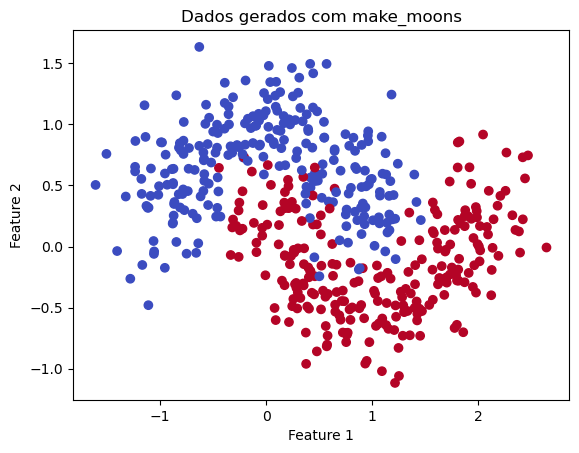

In [98]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dados gerados com make_moons")
plt.show()

## 3. Separação dos dados em treino e teste

Os dados foram separados em dois conjuntos:

- **80% para treino:** utilizados para o modelo aprender os padrões dos dados.
- **20% para teste:** reservados para avaliar o modelo em dados que não foram utilizados durante o treinamento.

Foi utilizado `stratify=y` para preservar aproximadamente a mesma proporção das classes 0 e 1 nos conjuntos de treino e teste.

O conjunto de teste será mantido separado durante o desenvolvimento e utilizado posteriormente para avaliar a capacidade de generalização do modelo.

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [100]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 2)
(100, 2)
(400,)
(100,)


## 4. Bias e Variance — Comparando a complexidade dos modelos

Para observar o efeito da complexidade, serão comparadas árvores de decisão com diferentes profundidades.

A profundidade (`max_depth`) controla o quanto a árvore pode crescer e criar regras para separar os dados.

Neste estudo serão avaliados:

- **Modelo simples:** `max_depth=1`
- **Modelo intermediário:** `max_depth=4`
- **Modelo complexo:** `max_depth=None`

O objetivo não é assumir previamente qual modelo é melhor, mas observar como o aumento da complexidade afeta o aprendizado e a capacidade de generalização.

### 4.1 Modelo simples — `max_depth=1`

Neste primeiro modelo, limitamos a árvore a uma profundidade máxima de 1.

Essa restrição reduz sua flexibilidade e permite observar o comportamento de um modelo com **Bias mais alto**.

In [101]:
modelo_simples = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

In [102]:
modelo_simples.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=1, random_state=42)

### 4.2 Avaliação do modelo simples

Após o treinamento, o modelo é utilizado para realizar previsões sobre o conjunto de teste.

As previsões são comparadas com os valores reais (`y_test`) para calcular a acurácia.

Também avaliamos a acurácia no conjunto de treino para comparar o comportamento do modelo nos dados que ele utilizou para aprender e nos dados que não foram utilizados no treinamento.

In [103]:
y_pred = modelo_simples.predict(X_test)

In [104]:
print(y_pred.shape)
print(y_pred[:10])

(100,)
[1 0 1 1 1 1 1 0 1 1]


In [105]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.81


In [106]:
y_pred_train = modelo_simples.predict(X_train)

accuracy_train = accuracy_score(y_train, y_pred_train)

print("Acurácia treino:", accuracy_train)
print("Acurácia teste:", accuracy)

Acurácia treino: 0.8375
Acurácia teste: 0.81


### Resultado — Modelo simples

- **Acurácia treino:** 83,75%
- **Acurácia teste:** 81%

Os resultados de treino e teste estão próximos, indicando pouca diferença de desempenho entre os dois conjuntos.

Porém, essa proximidade não significa, sozinha, que o modelo seja bom. Como a árvore possui `max_depth=1`, sua baixa complexidade pode limitar sua capacidade de aprender padrões mais complexos dos dados, caracterizando um comportamento de **Bias mais alto** e possível **underfitting**.

Por isso, serão testados modelos com maior complexidade.

### 4.3 Modelo intermediário — `max_depth=4`

Neste segundo modelo, aumentamos a profundidade máxima da árvore para 4.

O objetivo é dar maior flexibilidade ao modelo para aprender padrões mais complexos e observar o impacto dessa mudança no desempenho de treino e teste.

In [107]:
modelo_medio = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

modelo_medio.fit(X_train, y_train)

pred_train_medio = modelo_medio.predict(X_train)
pred_test_medio = modelo_medio.predict(X_test)

acc_train_medio = accuracy_score(y_train, pred_train_medio)
acc_test_medio = accuracy_score(y_test, pred_test_medio)

print("Acurácia treino:", acc_train_medio)
print("Acurácia teste:", acc_test_medio)

Acurácia treino: 0.91
Acurácia teste: 0.89


### Resultado — Modelo intermediário

- **Acurácia treino:** 91%
- **Acurácia teste:** 89%

Ao aumentar a profundidade para `max_depth=4`, o modelo ganhou maior flexibilidade para aprender os padrões dos dados.

Houve melhora tanto no treino quanto no teste em relação ao modelo simples, mantendo uma diferença pequena entre os dois resultados.

Esse comportamento sugere que o aumento de complexidade foi útil para representar melhor os dados.

### 4.4 Modelo complexo — `max_depth=None`

Neste terceiro modelo, não definimos um limite máximo para a profundidade da árvore.

Isso permite que a árvore aumente sua complexidade e crie regras mais específicas para representar os dados de treinamento.

Uma maior complexidade aumenta a flexibilidade do modelo, mas também pode aumentar sua sensibilidade às particularidades da amostra, elevando o risco de **Variance alta e overfitting**.

Importante: `max_depth=None` não significa automaticamente que haverá overfitting. O comportamento precisa ser avaliado nos dados não utilizados no ajuste e por técnicas como validação cruzada.

In [108]:
modelo_complexo = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

modelo_complexo.fit(X_train, y_train)

pred_train_complexo = modelo_complexo.predict(X_train)
pred_test_complexo = modelo_complexo.predict(X_test)

acc_train_complexo = accuracy_score(y_train, pred_train_complexo)
acc_test_complexo = accuracy_score(y_test, pred_test_complexo)

print("Acurácia treino:", acc_train_complexo)
print("Acurácia teste:", acc_test_complexo)

Acurácia treino: 1.0
Acurácia teste: 0.94


### Resultado — Modelo complexo

- **Acurácia treino:** 100%
- **Acurácia teste:** 94%

O modelo sem limite de profundidade conseguiu se ajustar perfeitamente aos dados de treinamento.

Esse resultado indica uma maior capacidade de adaptação aos dados e levanta uma **suspeita de maior Variance**, já que o modelo possui flexibilidade para aprender particularidades da amostra.

Porém, não podemos concluir overfitting apenas pela complexidade ou pela acurácia de treino de 100%. O desempenho no teste permaneceu alto.

Para investigar melhor a estabilidade e a capacidade de generalização dos modelos, utilizaremos **validação cruzada**.

## 5. Validação cruzada

Até aqui avaliamos os modelos utilizando uma única divisão entre treino e teste.

Para analisar com maior segurança o comportamento dos modelos, utilizaremos **Cross Validation com 5 folds** sobre os dados de treinamento.

Em cada rodada, uma parte dos dados de treino é utilizada para validação e as demais para treinamento.

Serão observados:

- a acurácia obtida em cada fold;
- a média das acurácias;
- o desvio padrão entre os resultados.

A média ajuda a avaliar o desempenho geral, enquanto o desvio padrão ajuda a observar a variação do desempenho entre os folds.

In [109]:
from sklearn.model_selection import cross_val_score

In [110]:
scores_simples = cross_val_score(
    modelo_simples,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(scores_simples)
print("Média:", scores_simples.mean())
print("Desvio padrão:", scores_simples.std())

[0.825  0.825  0.8375 0.8125 0.825 ]
Média: 0.825
Desvio padrão: 0.007905694150420955


In [111]:
scores_medio = cross_val_score(
    modelo_medio,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(scores_medio)
print("Média:", scores_medio.mean())
print("Desvio padrão:", scores_medio.std())

[0.9125 0.925  0.9    0.875  0.9125]
Média: 0.9049999999999999
Desvio padrão: 0.016955824957813177


In [112]:
scores_complexo = cross_val_score(
    modelo_complexo,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(scores_complexo)
print("Média:", scores_complexo.mean())
print("Desvio padrão:", scores_complexo.std())

[0.925  0.925  0.9625 0.95   0.95  ]
Média: 0.9425000000000001
Desvio padrão: 0.014999999999999979


### 5.1 Comparação da validação cruzada

| Modelo | Profundidade | Média da CV | Desvio padrão |
|---|---:|---:|---:|
| Simples | 1 | 82,50% | 0,79% |
| Intermediário | 4 | 90,00% | 1,70% |
| Complexo | None | 94,25% | 1,50% |

### Interpretação

O **modelo simples** apresentou o menor desvio padrão, indicando resultados mais consistentes entre os folds. Porém, também apresentou a menor acurácia média (82,5%). Isso mostra que baixa variabilidade entre os folds, isoladamente, não significa melhor desempenho.

O **modelo intermediário** aumentou a acurácia média para 90%, embora tenha apresentado maior variação entre os folds.

O **modelo complexo** apresentou a maior média de validação cruzada (94,25%) e desvio padrão de aproximadamente 1,5%. Apesar de possuir maior flexibilidade e ter atingido 100% de acurácia no treino, os resultados da validação cruzada permaneceram altos e relativamente consistentes.

Portanto, a maior complexidade aumenta o **risco** de alta Variance e overfitting, mas não permite concluir que eles estejam ocorrendo apenas pela profundidade da árvore. É necessário observar o comportamento do modelo em dados não utilizados no ajuste.

## 6. Visualização das fronteiras de decisão

Para visualizar o efeito da complexidade, comparamos as fronteiras de decisão produzidas pelos três modelos.

As regiões coloridas representam as classes previstas pelo modelo, enquanto os pontos representam as observações reais.

A comparação permite observar como o aumento da profundidade torna a fronteira de decisão mais flexível e adaptada aos dados.

In [113]:
def plot_decision_boundary(modelo, X, y, titulo, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    previsoes = modelo.predict(grid)
    previsoes = previsoes.reshape(xx.shape)

    ax.contourf(xx, yy, previsoes, alpha=0.25, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=25)

    ax.set_title(titulo)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

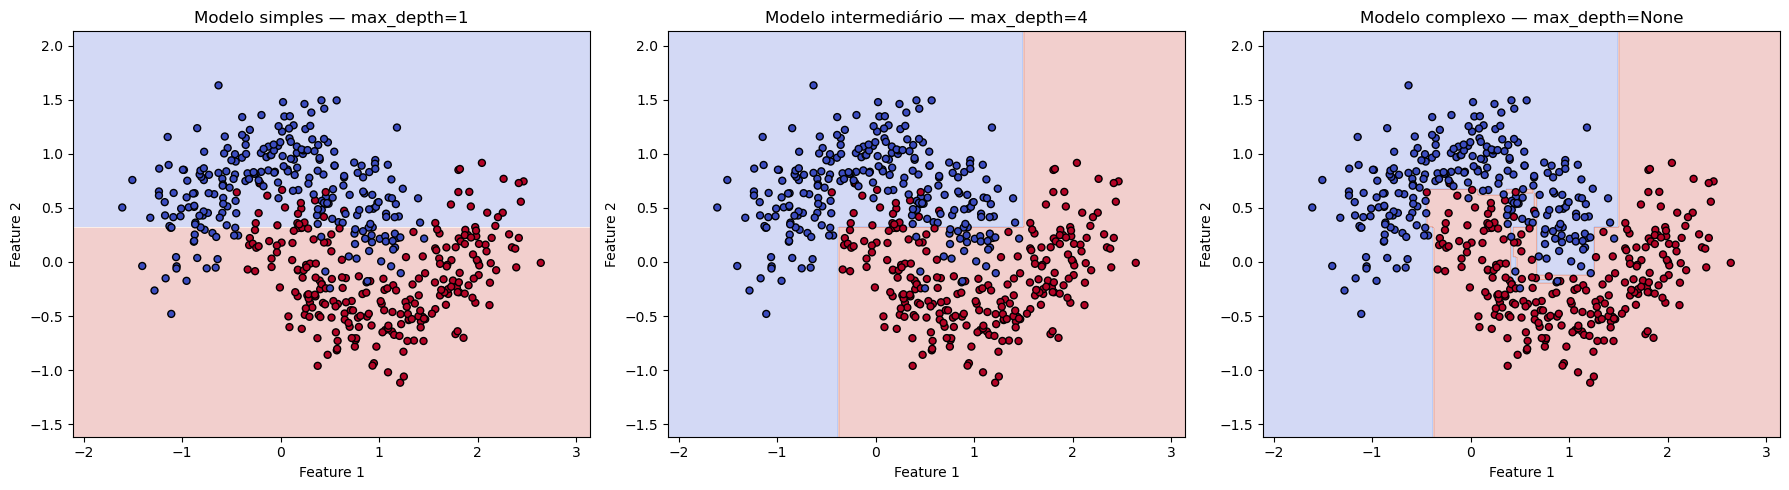

In [114]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_decision_boundary(
    modelo_simples,
    X,
    y,
    "Modelo simples — max_depth=1",
    axes[0]
)

plot_decision_boundary(
    modelo_medio,
    X,
    y,
    "Modelo intermediário — max_depth=4",
    axes[1]
)

plot_decision_boundary(
    modelo_complexo,
    X,
    y,
    "Modelo complexo — max_depth=None",
    axes[2]
)

plt.tight_layout()
plt.show()

### Interpretação das fronteiras de decisão

**Modelo simples — `max_depth=1`**

Apresenta uma fronteira bastante simples e rígida. A baixa flexibilidade dificulta representar adequadamente o formato dos dados, comportamento associado a **Bias mais alto** e possível underfitting.

**Modelo intermediário — `max_depth=4`**

Com o aumento da profundidade, o modelo ganha flexibilidade e consegue representar melhor o padrão observado nos dados.

**Modelo complexo — `max_depth=None`**

Sem limite de profundidade, o modelo possui maior liberdade para criar divisões e se adaptar aos dados. Essa flexibilidade aumenta sua capacidade de representar particularidades da amostra e, consequentemente, o risco de **Variance alta e overfitting**.

Entretanto, maior complexidade não implica automaticamente overfitting. Neste experimento, o modelo complexo apresentou bons resultados na validação cruzada, reforçando a necessidade de avaliar generalização em vez de concluir apenas pela complexidade do modelo.

# Parte 2 — Curva ROC e AUC

## 7. Scores e probabilidades

Após analisar Bias, Variance e generalização, vamos avaliar a capacidade de discriminação do classificador por meio da Curva ROC e da AUC.

O método `predict_proba()` retorna, para cada observação, os scores/probabilidades estimadas para cada classe.

Esses valores serão utilizados para estudar diferentes thresholds e observar o impacto sobre TPR e FPR.

In [115]:
probabilidades = modelo_complexo.predict_proba(X_test)

print(probabilidades[:10])

[[0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]]


In [116]:
probabilidades_medio = modelo_medio.predict_proba(X_test)

print(probabilidades_medio[:10])

[[0.         1.        ]
 [1.         0.        ]
 [1.         0.        ]
 [0.         1.        ]
 [0.         1.        ]
 [0.37037037 0.62962963]
 [0.1        0.9       ]
 [0.67391304 0.32608696]
 [0.37037037 0.62962963]
 [0.         1.        ]]


In [117]:
y_score = probabilidades_medio[:, 1]

print(y_score[:10])

[1.         0.         0.         1.         1.         0.62962963
 0.9        0.32608696 0.62962963 1.        ]


### 7.1 Score da classe positiva e threshold

`predict_proba()` retorna duas probabilidades para cada observação:

- coluna 0: score/probabilidade estimada para a classe `0`;
- coluna 1: score/probabilidade estimada para a classe `1`.

Como a classe positiva neste estudo é `1`, selecionamos a segunda coluna e armazenamos seus valores em `y_score`.

O **threshold** é o ponto de corte utilizado para transformar esse score em uma decisão de classe.

Por exemplo, com `threshold = 0,50`:

- score ≥ 0,50 → previsão `1`;
- score < 0,50 → previsão `0`.

A alteração do threshold não retreina o modelo. Ela apenas modifica a regra utilizada para transformar os scores em classificações.

In [118]:
threshold = 0.50

y_pred_threshold = (y_score >= threshold).astype(int)

print(y_pred_threshold[:10])
print(y_test[:10])

[1 0 0 1 1 1 1 0 1 1]
[1 0 0 1 1 1 1 0 0 0]


In [119]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_threshold
).ravel()

print("VP:", tp)
print("FP:", fp)
print("VN:", tn)
print("FN:", fn)

VP: 46
FP: 7
VN: 43
FN: 4


### 7.2 Construindo manualmente um ponto da Curva ROC

Com `threshold = 0,50`, a matriz de confusão apresentou:

- **VP = 46:** positivos identificados corretamente;
- **FP = 7:** negativos classificados incorretamente como positivos;
- **VN = 43:** negativos identificados corretamente;
- **FN = 4:** positivos classificados incorretamente como negativos.

A partir desses valores podemos calcular o TPR e o FPR.

**True Positive Rate (TPR):**

TPR = VP / (VP + FN)

TPR = 46 / (46 + 4) = **0,92**

Isso significa que o modelo identificou corretamente **92% dos positivos reais**.

**False Positive Rate (FPR):**

FPR = FP / (FP + VN)

FPR = 7 / (7 + 43) = **0,14**

Isso significa que **14% dos negativos reais foram classificados incorretamente como positivos**.

Portanto, para esse threshold, temos o ponto da ROC:

**(FPR, TPR) = (0,14; 0,92)**

In [120]:
threshold = 0.30

y_pred_threshold = (y_score >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_threshold
).ravel()

tpr = tp / (tp + fn)
fpr = fp / (fp + tn)

print("VP:", tp)
print("FP:", fp)
print("VN:", tn)
print("FN:", fn)

print("TPR:", tpr)
print("FPR:", fpr)

VP: 49
FP: 19
VN: 31
FN: 1
TPR: 0.98
FPR: 0.38


### 7.3 Efeito da alteração do threshold

Ao reduzir o threshold de **0,50 para 0,30**, mais observações passam a ser classificadas como positivas.

| Threshold | TPR | FPR |
|---:|---:|---:|
| 0,50 | 92% | 14% |
| 0,30 | 98% | 38% |

Com o threshold de **0,30**, o modelo identificou 98% dos positivos reais, mas também classificou incorretamente 38% dos negativos como positivos.

Isso demonstra o trade-off provocado pela alteração do threshold:

- thresholds menores tendem a aumentar o TPR;
- porém, também podem aumentar o FPR.

A escolha do threshold operacional depende do contexto do negócio e dos custos associados aos falsos positivos e falsos negativos.

## 8. Construção da Curva ROC

Até aqui calculamos manualmente TPR e FPR para thresholds específicos.

A função `roc_curve()` realiza esse processo para diferentes pontos de corte, retornando:

- `fpr`: False Positive Rate;
- `tpr`: True Positive Rate;
- `thresholds`: valores de corte associados aos pontos da curva.

Cada combinação `(FPR, TPR)` representa um ponto da Curva ROC.

In [121]:
from sklearn.metrics import roc_curve

In [122]:
fpr, tpr, thresholds = roc_curve(y_test, y_score)

In [123]:
print("FPR:", fpr)
print("TPR:", tpr)
print("Thresholds:", thresholds)

FPR: [0.   0.02 0.02 0.14 0.38 1.  ]
TPR: [0.   0.66 0.74 0.92 0.98 1.  ]
Thresholds: [       inf 1.         0.9        0.62962963 0.32608696 0.        ]


In [124]:
import pandas as pd

tabela_roc = pd.DataFrame({
    "Threshold": thresholds,
    "FPR": fpr,
    "TPR": tpr
})

tabela_roc

,Threshold,FPR,TPR
0,inf,0.00,0.00
1,1.000000,0.02,0.66
2,0.900000,0.02,0.74
3,0.629630,0.14,0.92
4,0.326087,0.38,0.98
5,0.000000,1.00,1.00


### Observação sobre os thresholds

A função `roc_curve()` não precisa retornar todos os valores possíveis de threshold.

Ela considera os pontos relevantes em que a classificação e, consequentemente, os valores de TPR e FPR se alteram.

Por isso, um threshold utilizado manualmente, como `0,50`, pode não aparecer explicitamente na tabela, mesmo produzindo um ponto equivalente da curva.

## 9. Visualização da Curva ROC

A Curva ROC representa o comportamento do classificador em diferentes thresholds.

- **Eixo Y — TPR:** proporção dos positivos reais corretamente identificados.
- **Eixo X — FPR:** proporção dos negativos reais classificados incorretamente como positivos.

Quanto mais a curva se aproxima do **canto superior esquerdo**, maior tende a ser a capacidade de discriminação do modelo.

A linha diagonal tracejada representa um classificador sem capacidade de discriminação útil, equivalente a um ranking aleatório, com **AUC = 0,5**.

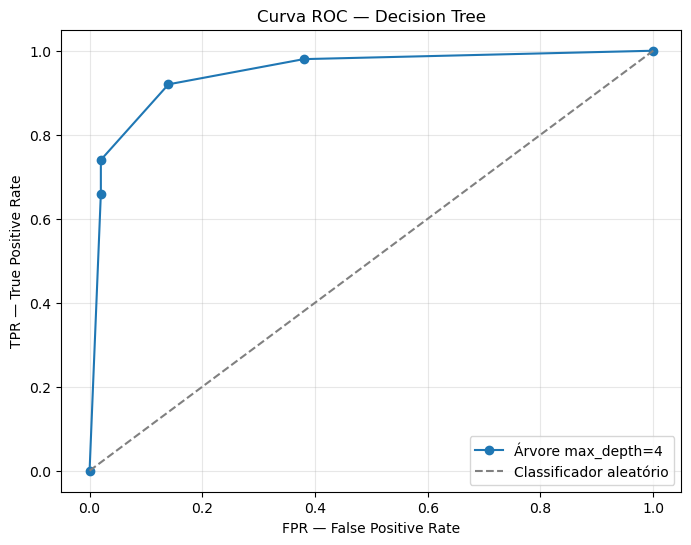

In [125]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    marker="o",
    label="Árvore max_depth=4"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Classificador aleatório"
)

plt.xlabel("FPR — False Positive Rate")
plt.ylabel("TPR — True Positive Rate")
plt.title("Curva ROC — Decision Tree")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 10. Área sob a curva — AUC

A **AUC (Area Under the Curve)** resume em um único valor a capacidade de discriminação representada pela Curva ROC.

Quanto mais próxima de 1, maior a capacidade do modelo de atribuir scores mais altos às observações positivas do que às negativas.

A AUC **não representa acurácia** e não depende da escolha de um único threshold.

In [126]:
from sklearn.metrics import auc

roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.948


### Interpretação da AUC

O modelo apresentou:

**AUC = 0,948**

Esse resultado indica uma alta capacidade de discriminação entre as classes.

Uma interpretação probabilística é:

> Ao escolher aleatoriamente uma observação positiva e uma negativa, existe aproximadamente **94,8% de chance de o modelo atribuir um score maior à observação positiva**.

Isso não significa que o modelo possui 94,8% de acurácia.

A AUC avalia a capacidade de **ranking/discriminação** do modelo, enquanto a classificação final em 0 ou 1 depende da escolha de um **threshold**.

# 11. Conclusões

Neste estudo foi possível observar dois aspectos importantes da avaliação de modelos de classificação.

### Bias e Variance

O aumento da complexidade tornou as árvores mais flexíveis e capazes de representar padrões mais detalhados dos dados.

Modelos muito simples podem apresentar Bias alto e underfitting. Por outro lado, modelos muito complexos possuem maior risco de alta Variance e overfitting.

Entretanto, complexidade elevada não significa automaticamente overfitting. A capacidade de generalização deve ser avaliada utilizando dados não utilizados no ajuste e técnicas como validação cruzada.

### ROC e AUC

A Curva ROC permite observar o trade-off entre TPR e FPR em diferentes thresholds.

A alteração do threshold modifica o ponto operacional do modelo e sua escolha deve considerar os custos de falsos positivos e falsos negativos para o negócio.

Neste experimento, o modelo intermediário apresentou **AUC = 0,948**, indicando alta capacidade de discriminação entre as classes.

Portanto, diferentes ferramentas respondem a perguntas diferentes:

- **Bias / Variance e validação cruzada:** ajudam a avaliar aprendizado e generalização.
- **ROC-AUC:** ajuda a avaliar a capacidade de discriminação/ranking.
- **Threshold:** define a regra operacional para transformar scores em decisões.